In [1]:
# data analysis
import pandas as pd
import numpy as np
import math

#prophet time series
from prophet import Prophet

# data visualization
import matplotlib.pyplot as plt

# numpy output display setup
np.set_printoptions(suppress=True)

# pandas output display setup
pd.set_option('display.float_format', lambda x: '%.2f' % x) 
pd.options.display.float_format = '{:,}'.format

# Quiz _Timeseries & Forecasting_

Kuis ini merupakan bagian dari proses penilaian *Corporate Training Algoritma*. Selamat atas selesainya materi _Timeseries and Forecasting_ dalam Machine Learning. Kami akan melakukan penilaian berupa kuis untuk menguji praktek teknik pembuatan model _Timeseries_ yang sudah Anda pelajari. Pengerjaan kuis diharapkan dapat dilakukan di dalam kelas, silakan hubungi tim instruktur kami jika Anda melewatkan kesempatan untuk mengambilnya di kelas.

Untuk menyelesaikan penilian ini, Anda diminta untuk membuat model _Timeseries_ yang digunakan untuk memprediksi harga minyak selama 1 tahun mendatang.

# Data Cleansing & PreProcessing

Pertama, kita akan mulai dari menyiapkan dan melakukan ekplorasi pada data. Pada kuis ini, Anda akan menggunakan data harga minyak . Data disimpan dalam bentuk `.csv` di dalam folder `data_input` sebagai file `BrentOilPrices.csv`. Bacalah data tersebut menggunakan `pd.read_csv()` dan simpanlah sebagai objek `oil_prices`. Sebelum membuat model _Timeseries_. Anda perlu melakukan analisis ekplorasi data untuk memahami data tersebut. Lihatlah struktur data kita! Anda dapat menggunakan `dtypes` atau `info()`.


## Read the Data

In [2]:
# code here
# membaca data BrentOilPrices.csv dari folder data_input
oil_prices = pd.read_csv('data_input/BrentOilPrices.csv')
oil_prices.head()

,Date,Price
0,20-May-87,18.63
1,21-May-87,18.45
2,22-May-87,18.55
3,25-May-87,18.6
4,26-May-87,18.63


In [3]:
oil_prices.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9011 entries, 0 to 9010
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    9011 non-null   object 
 1   Price   9011 non-null   float64
dtypes: float64(1), object(1)
memory usage: 140.9+ KB


Data `oil_prices` terdiri dari 2 kolom dan 9011 baris. Data ini merupakan data historis harga minyak. Dibawah ini merupaka informasi lebih lanjut tentang variabel yang terdapat pda dataset:

  - `Date`: informasi tanggal
  - `Price`: Harga minyak per barrel (dollar)
  

## Transform Data Types

Ubahlah data dengan informasi tanggal ke dalam bentuk datetime menggunakan `pd.to_datetime()`. Setelah itu, urutkan data berdasarkan tanggalnya.

In [4]:
# code here
# membaca data BrentOilPrices.csv dari folder data_input
oil_prices = pd.read_csv('data_input/BrentOilPrices.csv')
oil_prices.head()

,Date,Price
0,20-May-87,18.63
1,21-May-87,18.45
2,22-May-87,18.55
3,25-May-87,18.6
4,26-May-87,18.63


In [5]:
# code here
# membaca data BrentOilPrices.csv dari folder data_input
oil_prices = pd.read_csv('data_input/BrentOilPrices.csv')
oil_prices.head()

# code here
# mengubah tipe data
oil_prices['Date'] = pd.to_datetime(oil_prices['Date'], format="mixed")

# melakukan pengurutan kolom date secara ascending
oil_prices = oil_prices.sort_values('Date')
oil_prices.head()

,Date,Price
0,1987-05-20,18.63
1,1987-05-21,18.45
2,1987-05-22,18.55
3,1987-05-25,18.6
4,1987-05-26,18.63


In [6]:
# pemeriksaan ulang tipe data
oil_prices.dtypes

Date     datetime64[ns]
Price           float64
dtype: object

___
1. Berdasarkan informasi tanggal yang kita miliki, format apa yang tepat digunakan untuk mengubah informasi tanggal ke dalam bentuk datetime? 
  - [ ] `"%d-%b-%y"`
  - [ ] `"%d-%B-%y"`
  - [ ] `"mixed"`
  - [ ] `"%b%d,%Y`
___

# Exploratory Data Analysis



## Statistic Summary

Mari kita mulai dengan meninjau deskripsi statistik dari data kita. Melakukan deskripsi statistik adalah langkah penting untuk memahami karakteristik dasar dari setiap kolom dalam kumpulan data kita. Kita dapat menggunakan metode `.describe()`untuk mendapatkan gambaran umum mengenai distribusi dan variabilitas data kita sebelum melangkah ke tahap analisis yang lebih mendalam.

In [7]:
# code here
# menampilkan deskripsi statistik data 
oil_prices.describe()


,Date,Price
count,9011,"9,011.0"
mean,2005-02-10 23:46:53.760958720,48.42078237709467
min,1987-05-20 00:00:00,9.1
25%,1996-03-20 12:00:00,19.05
50%,2005-02-02 00:00:00,38.57
75%,2014-01-09 12:00:00,70.09
max,2022-11-14 00:00:00,143.95
std,NaN,32.86010995167221


## Visualization

Salah satu aspek penting dalam analisis _Time Series_ adalah melakukan analisis eksplorasi visual karena membantu mengidentifikasi pola, tren, dan anomali dalam data secara intuitif, sehingga memudahkan dalam mengambil keputusan yang lebih tepat dan efektif

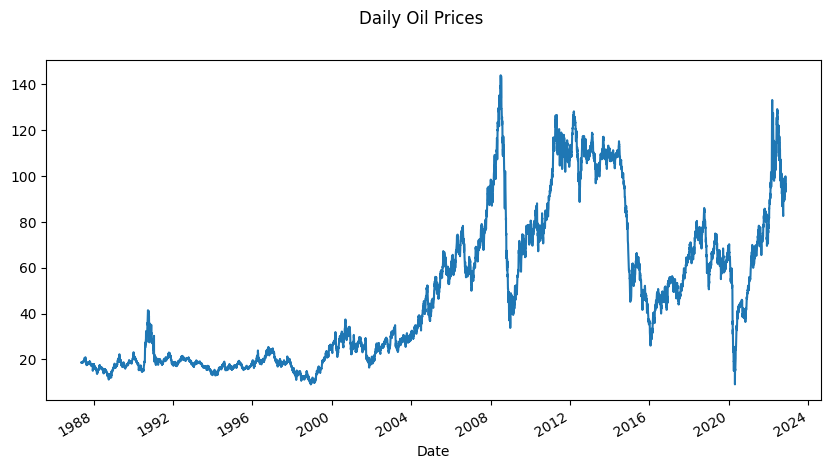

In [8]:
# jalankan code berikut
import matplotlib.pyplot as plt
oil_prices.set_index('Date')['Price'].plot(subplots=True,figsize=(10, 5))
plt.suptitle('Daily Oil Prices')
plt.show()

---
2. Kapankah harga minyak mencapai harga tertinggi dan terrendah ?
- [ ] 03 Juli 2008 dan 12 Oktober 1998
- [ ] 12 Oktober 1998 dan 03 Juli 2008
- [ ] 07 Maret 2008 dan 10 Desember 1998
- [ ] 03 Juli 2008 dan 10 Desember 1998

---

In [9]:
# your code here
# menampilkan tanggal dengan price tertinggi
max_price_date = oil_prices.loc[oil_prices['Price'].idxmax(), 'Date']
max_price_date


Timestamp('2008-07-03 00:00:00')

In [10]:
# menampilkan tanggan dengan price terendah
min_price_date = oil_prices.loc[oil_prices['Price'].idxmin(), 'Date']
min_price_date

Timestamp('1998-12-10 00:00:00')

# Modeling Using `Prophet`

---
3. Metode perhitungan apa yang digunakan `prophet` untuk menggambarkan kondisi time series dan melakukan forecasting?

- [ ] Component Decompose
- [ ] General Additive Model
- [ ] Autoregressive Integrated Moving Average
- [ ] Holt Winters Exponential Smoothing

---

4. Berikut ini adalah kelebihan dari `prophet` yang tidak dimiliki oleh metode time series konvensional, kecuali ...

- [ ] fleksibilitas dalam mengatur komponen trend dan seasonal
- [ ] melakukan forecasting masa depan yang sangat panjang
- [ ] menambahkan efek holiday/event
- [ ] tidak membutuhkan pemahaman statistik yang mendalam

---


## Prepare dataframe contains `ds` and `y` columns

`Prophet` hanya dapat menerima input data dengan judul kolom `ds` dan `y`, oleh karena itu ubahlah judul kolom pada data yang kita miliki.

In [11]:
# code here
# mengubah nama kolom sesuai format prophet
oil_prices = oil_prices.rename(columns = {'Date': 'ds',
                                          'Price':'y'}) 

## Cross Validation

Pada kasus ini, kita akan mengambil data setelah tanggal 31 Desember 2021 untuk digunakan sebagai data test. Artinya kita akan memiliki 4 bulan data yang akan kita predict.

In [12]:
# melakukan cross validation
cutoff = "2021-12-31"

# for fitting data
train = oil_prices[oil_prices['ds'] <= cutoff]
# for evaluation data
test = oil_prices[oil_prices['ds'] > cutoff]

print(f'Train size: {train.shape}')
print(f'Test size: {test.shape}')

Train size: (8791, 2)
Test size: (220, 2)


## Fitting Model

Silakan bangun sebuah model `prophet` tanpa menentukan parameter apa-apa (gunakan nilai defaultnya) setelah itu lakukan fitting kepada data `train`.

In [13]:
# code here
# membuat model default
model = Prophet()
model.fit(train)

20:25:01 - cmdstanpy - INFO - Chain [1] start processing
20:25:05 - cmdstanpy - INFO - Chain [1] done processing


## Forecasting

Untuk kebutuhan evaluasi, kita akan menggunakan informasi waktu dari data asli kita untuk kita gunakan pada method `.predict()`.

In [16]:
# prepare dataframe for predict input
fulltime_df = oil_prices[['ds']]

# forecast
fc = model.predict(fulltime_df)

## Evaluasi

Pada bagian ini, kita akan membandingkan nilai error data train dengan data test kita. Silakan jalankan kode berikut tanpa mengubah apapun.

In [17]:
from sklearn.metrics import mean_absolute_percentage_error

train_mape = mean_absolute_percentage_error(y_true=train['y'], 
                                     y_pred=fc[fc['ds'] <= cutoff]['yhat']) 

test_mape = mean_absolute_percentage_error(y_true=test['y'], 
                                     y_pred=fc[fc['ds'] > cutoff]['yhat']) 

print(f"MAPE Train: {round(train_mape, 5)*100}%")
print(f"MAPE Test: {round(test_mape, 5)*100}%")

MAPE Train: 15.467%
MAPE Test: 38.576%


---
5. Jika kita menggunakan nilai 10 persen sebagai batas toleransi overfit, berdasarkan nilai MAPE yang sudah ditunjukkan di atas maka dapat disimpulkan bahwa model kita ..

- [ ] overfit
- [ ] underfit
- [ ] optimal
---

## Visualize the model

Dengan model yang sudah dibuat, kita akan melakukan interpretasi berdasarkan komponen-komponen time seriesnya.

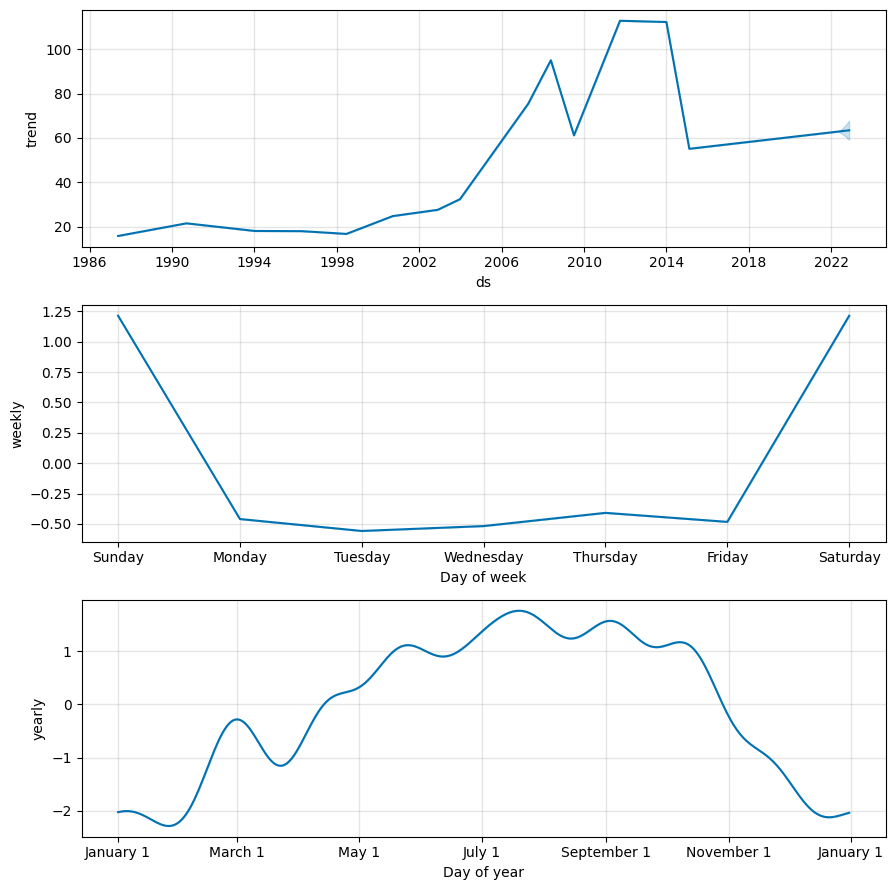

In [18]:
fig = model.plot_components(fc)

---
6. Jika kita lakukan visualisasi pada komponen time seriesnya, manakah statement di bawah ini yang **KURANG TEPAT** berdasarkan model yang kita buat?

- [ ] berdasarkan pola mingguan, penjualan umumnya rendah di weekdays dan tinggi di weekend.
- [ ] berdasarkan pola tahunan, penjualan umumnya rendah pada pertengahan tahun
- [ ] secara keseluruhan, dari tahun 1986-2006, terdapat tren yang naik.
---
7. Manakah statement di bawah ini yang benar dari komponen seasonal pada model `prophet`?

- [ ] secara default kita memiliki komponen seasonal tahunan, bulanan, dan mingguan
- [ ] nilai Fourier order akan lebih baik diatur besar untuk seasonality yang lebih panjang
- [ ] pada data harian, komponen seasonal harian akan muncul secara otomatis
- [ ] komponen seasonal akan otomatis hilang jika kita menambahkan custom seasonality
---
